In [1]:
#Exploring ML workflow via KNN and housing prices, taken from Machine learning for Algorithmic Training Chapter 6

In [2]:
%pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler, scale
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
from yellowbrick.model_selection import ValidationCurve, LearningCurve

In [4]:
%matplotlib inline
sns.set_style('whitegrid')

In [5]:
house_sales = pd.read_csv('kc_house_data.csv')
house_sales = house_sales.drop(
    ['id','zipcode','lat','long','date'], axis=1)
house_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  sqft_living15  21613 non-null  int64  
 15  sqft_lot15     21613 non-null  int64  
dtypes: float64(3), int64(13)
memory usage: 2.6 MB


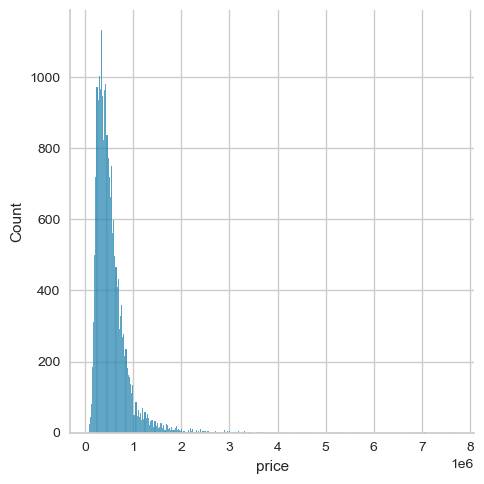

In [6]:
sns.displot(house_sales.price)
plt.tight_layout()
plt.show()

In [7]:
#log transforming to eliminate right skew
X = house_sales.drop('price', axis=1)
Y = np.log(house_sales.price)

In [8]:
#"Information Gain and Mutual Information are used to measure how much knowledge one variable provides about another. 
#They help optimize feature selection, split decision boundaries and improve model accuracy by reducing uncertainty in predictions."
# https://www.geeksforgeeks.org/machine-learning/information-gain-and-mutual-information-for-machine-learning/

In [9]:
mi = pd.Series(mutual_info_regression(X,Y), 
               index = X.columns).sort_values(ascending=False)

In [10]:
mi

sqft_living      0.348051
grade            0.347921
sqft_living15    0.272814
sqft_above       0.257640
bathrooms        0.207998
sqft_lot15       0.085231
bedrooms         0.080136
floors           0.076884
yr_built         0.075185
sqft_basement    0.071850
sqft_lot         0.062184
view             0.059486
waterfront       0.015166
condition        0.014159
yr_renovated     0.005878
dtype: float64

In [11]:
#retrieving top most important features
X = X.loc[:, mi.iloc[:10].index]

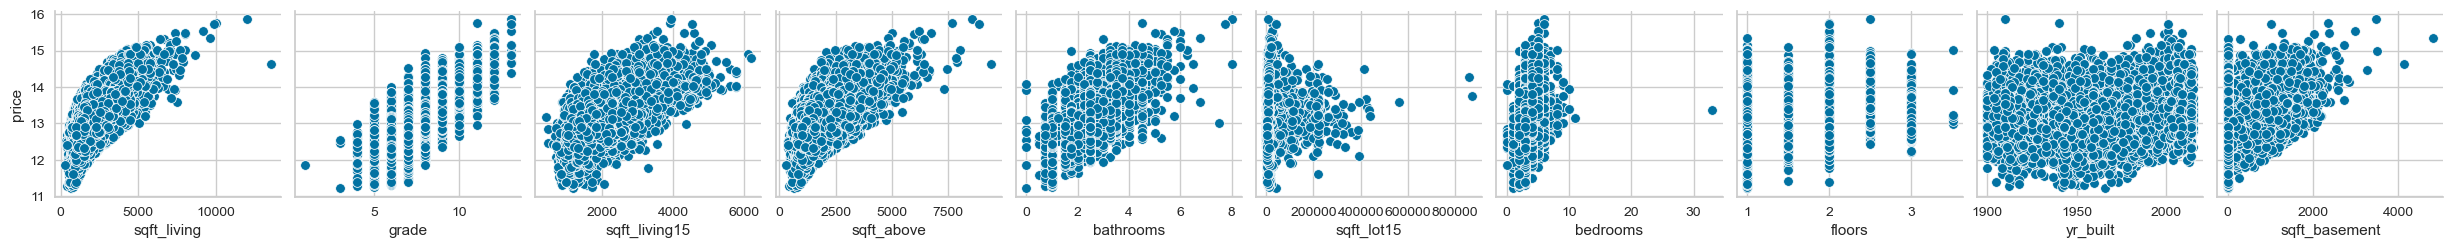

In [12]:
#pairplots
graphs = sns.pairplot(X.assign(price=Y), y_vars=['price'], x_vars=X.columns)
plt.show()

In [13]:
#looking at correlations using spearman ranking
# Spearman's Rank Correlation is a statistical measure of the strength and direction of the monotonic relationship between two continuous variables. Therefore, these attributes are ranked or put in the order of their preference. 
# It is denoted by the symbol "rho" (ρ) and can take values between -1 to +1
# https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sqft_living    21613 non-null  int64  
 1   grade          21613 non-null  int64  
 2   sqft_living15  21613 non-null  int64  
 3   sqft_above     21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_lot15     21613 non-null  int64  
 6   bedrooms       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   yr_built       21613 non-null  int64  
 9   sqft_basement  21613 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 1.6 MB


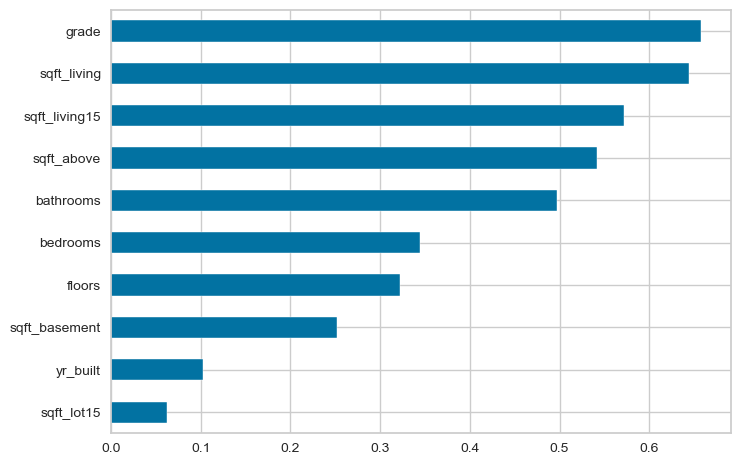

In [15]:
#Look at correlations
corr = X.apply(lambda x: spearmanr(x,Y)[0])
corr.sort_values().plot.barh()
plt.show()

In [16]:
#Standardizing variable to mean 0, std 1 so KNN more effective
XScaled = scale(X)

In [17]:
model = KNeighborsRegressor()
model.fit(X=XScaled, y=Y)

KNeighborsRegressor()

In [18]:
Y_Pred = model.predict(XScaled)

In [19]:
#Getting error metrics

In [20]:
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             mean_squared_log_error,
                             median_absolute_error,
                             explained_variance_score,
                             r2_score)

In [21]:
#Computing prediction error, the deviation from a predicted value
Prediction_Errors = Y - Y_Pred
Prediction_Errors.name = "Prediction Errors"

In [22]:
scores = {
    "rmse": np.sqrt(mean_squared_error(Y, Y_Pred)),
    "remsle": np.sqrt(mean_squared_log_error(Y, Y_Pred)),
    "mean_ae": mean_absolute_error(Y, Y_Pred),
    "median_ae": median_absolute_error(Y, Y_Pred),
    "r2score": explained_variance_score(Y, Y_Pred)
}

In [23]:
scores

{'rmse': np.float64(0.2554328483315968),
 'remsle': np.float64(0.018243063491673987),
 'mean_ae': 0.197088185727765,
 'median_ae': np.float64(0.15796823972598517),
 'r2score': 0.7650274674698165}

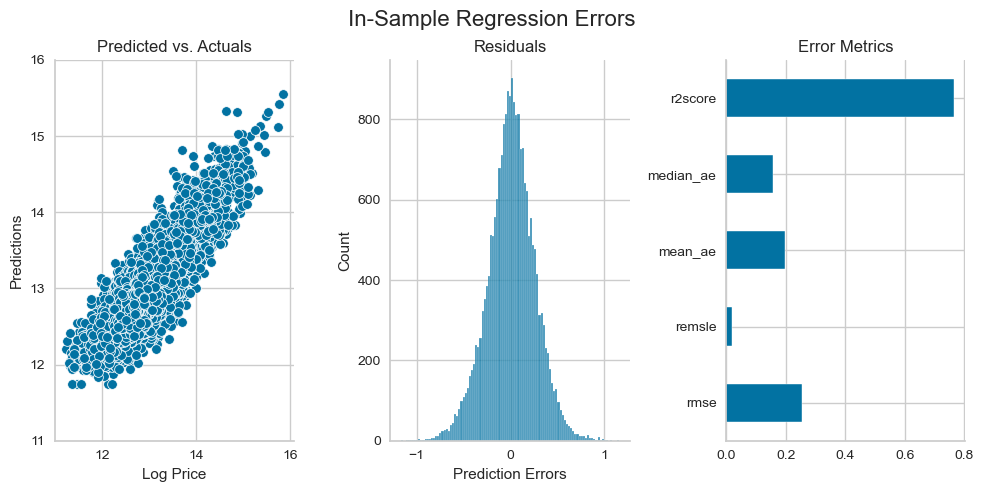

In [24]:
fig, axes = plt.subplots(ncols=3, figsize=(10,5))
sns.scatterplot(x=Y, y=Y_Pred, ax = axes[0])
axes[0].set_xlabel('Log Price')
axes[0].set_ylabel('Predictions')
axes[0].set_ylim(11, 16)
axes[0].set_title('Predicted vs. Actuals')
sns.histplot(Prediction_Errors, ax=axes[1])
axes[1].set_title('Residuals')
pd.Series(scores).plot.barh(ax=axes[2], title='Error Metrics')
fig.suptitle("In-Sample Regression Errors", fontsize=16)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.88)
plt.show()

In [25]:
#Cross Validation, finding best K for bias-variance trade-off

In [26]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true=y_true, y_pred=y_pred))

rmse_score = make_scorer(rmse)

In [27]:
cv_rmse = {}
n_neighbors = [1] + list(range(5,51,5))
for n in n_neighbors:
    pipe = Pipeline([('scaler', StandardScaler()),
                    ('knn', KNeighborsRegressor(n_neighbors=n))])
    cv_rmse[n] = cross_val_score(pipe,
                                X=X,
                                y=Y,
                                scoring=rmse_score,
                                cv=5)

In [28]:
cv_rmse = pd.DataFrame.from_dict(cv_rmse, orient='index')
best_n, best_rmse = cv_rmse.mean(1).idxmin(), cv_rmse.mean(1).min()
cv_rmse = cv_rmse.stack().reset_index()
cv_rmse.columns = ['n', 'fold', 'RMSE']

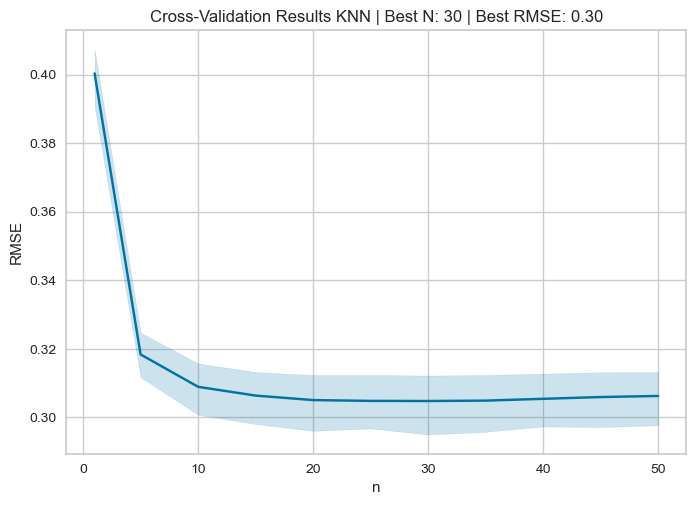

In [29]:
ax = sns.lineplot(x='n', y='RMSE', data=cv_rmse)
ax.set_title(f'Cross-Validation Results KNN | Best N: {best_n:d} | Best RMSE: {best_rmse:.2f}')
plt.show()

In [30]:
#Actuals vs Predicted

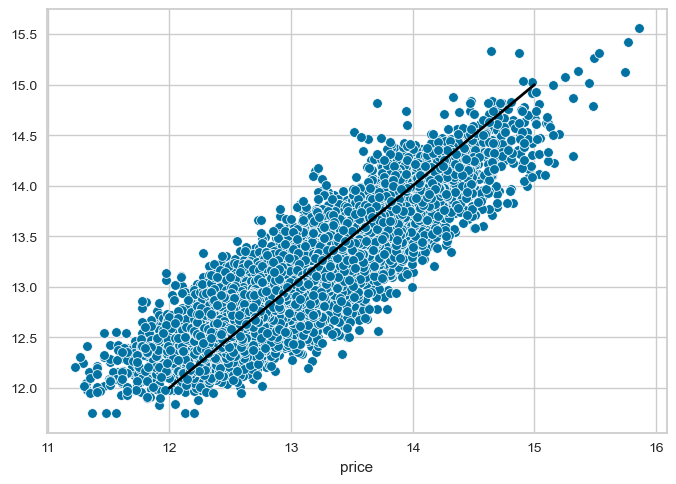

In [31]:
pipe = Pipeline([('scaler', StandardScaler()),
                 ('knn', KNeighborsRegressor(n_neighbors=best_n))])
y_pred = cross_val_predict(pipe, X, Y, cv=5)

ax = sns.scatterplot(x=Y, y=Y_Pred)
y_range = list(range(int(Y.min() + 1), int(Y.max() + 1)))
pd.Series(y_range, index=y_range).plot(ax=ax, lw=2, c='Black')
plt.show()

In [32]:
#Cross-Validation Errors
error = (Y-Y_Pred).rename("Prediction Errors")

In [33]:
scores = {
    'rmse': np.sqrt(mean_squared_error(y_true=Y, y_pred = Y_Pred)),
    'rmsle': np.sqrt(mean_squared_log_error(y_true = Y, y_pred = Y_Pred)),
    'mean_ae': mean_absolute_error(y_true = Y, y_pred = Y_Pred),
    'median_ae': median_absolute_error(y_true = Y, y_pred = Y_Pred),
    'r2score' : explained_variance_score(y_true = Y, y_pred = Y_Pred)    
}

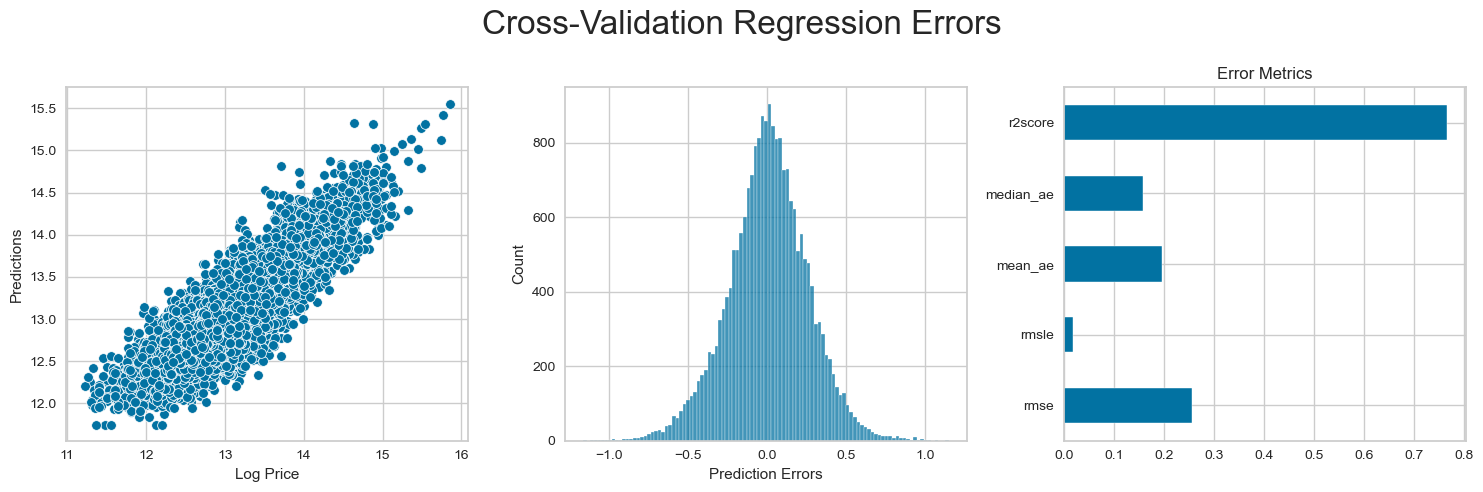

In [34]:
fig, axes = plt.subplots(ncols=3, figsize=(15,5))
sns.scatterplot(x=Y, y=Y_Pred, ax=axes[0])
axes[0].set_xlabel('Log Price')
axes[0].set_ylabel('Predictions')
sns.histplot(error, ax=axes[1])
pd.Series(scores).plot.barh(ax=axes[2], title='Error Metrics')
fig.suptitle('Cross-Validation Regression Errors', fontsize = 24)
fig.tight_layout()
plt.show()

In [35]:
pipe = Pipeline([('scaler', StandardScaler()),
                 ('knn', KNeighborsRegressor())])
n_folds = 5
n_neighbors = tuple(range(5, 101, 5))
param_grid = {'knn__n_neighbors': n_neighbors}

estimator = GridSearchCV(estimator=pipe,
                         param_grid=param_grid,
                         cv=n_folds,
                         scoring=rmse_score,
                        )
estimator.fit(X=X, y=Y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsRegressor())]),
             param_grid={'knn__n_neighbors': (5, 10, 15, 20, 25, 30, 35, 40, 45,
                                              50, 55, 60, 65, 70, 75, 80, 85,
                                              90, 95, 100)},
             scoring=make_scorer(rmse, response_method='predict'))

In [36]:
cv_results = estimator.cv_results_

In [37]:
test_scores = pd.DataFrame({fold: cv_results[f'split{fold}_test_score'] for fold in range(n_folds)},
                            index = n_neighbors).stack().reset_index()
test_scores.columns = ['k', 'fold', 'RMSE']

In [38]:
mean_rmse = test_scores.groupby('k').RMSE.mean()
best_k, best_score = mean_rmse.idxmin(), mean_rmse.min()

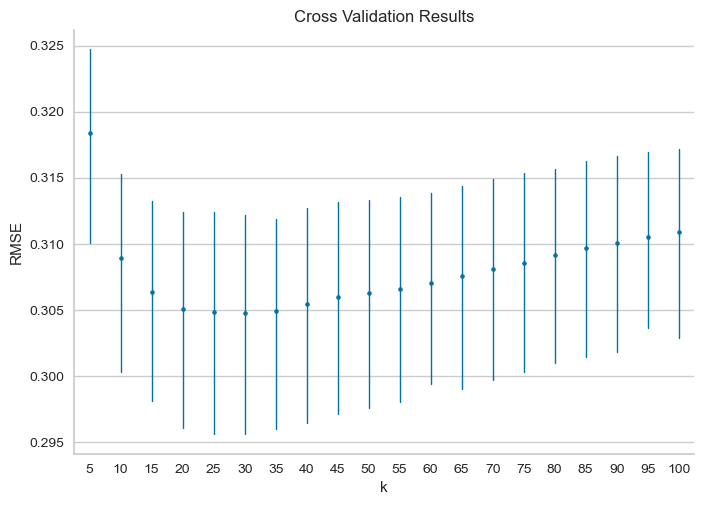

In [39]:
sns.pointplot(x='k', y='RMSE', data=test_scores, linewidth = 1, linestyle='none')
plt.title('Cross Validation Results')
sns.despine()
plt.show()

In [40]:
#TRAIN AND VALIDATION CURVES

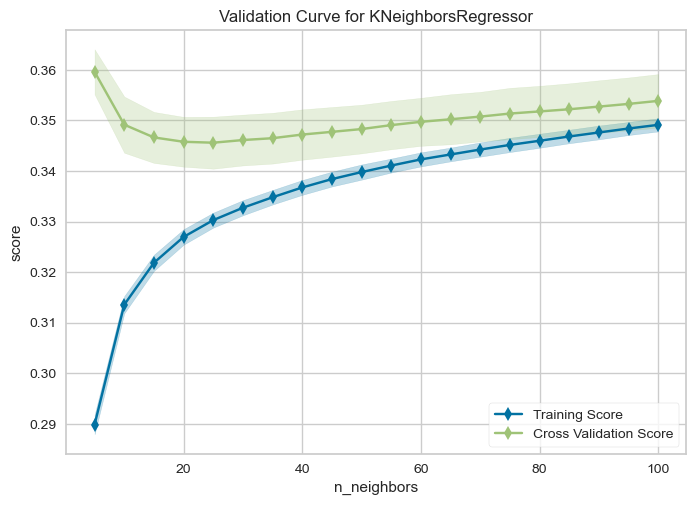

<Figure size 800x550 with 0 Axes>

In [41]:
fig, ax = plt.subplots()
val_curve = ValidationCurve(KNeighborsRegressor(),
                            param_name = 'n_neighbors',
                            param_range=n_neighbors,
                            cv=5,
                            scoring = rmse_score,
                            ax=ax)

val_curve.fit(X,Y)
val_curve.poof() #.show 
sns.despine()
plt.show()

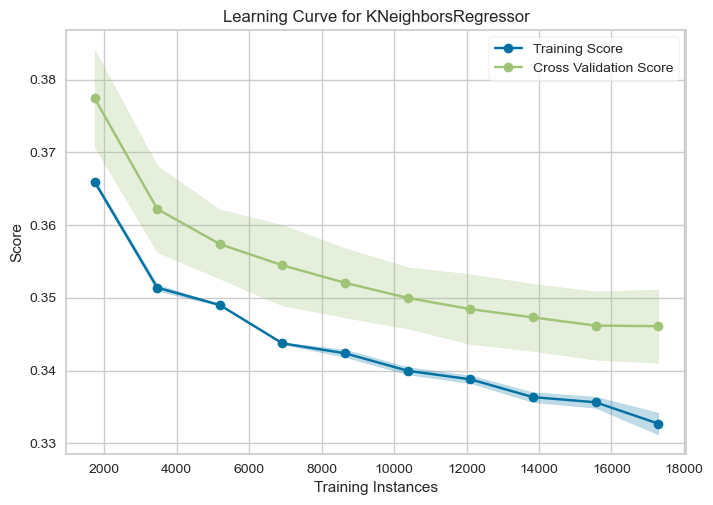

<Figure size 800x550 with 0 Axes>

In [42]:
fig, ax = plt.subplots()
l_curve = LearningCurve(KNeighborsRegressor(n_neighbors=best_k),
                        train_sizes=np.arange(.1, 1.01, .1),
                        scoring = rmse_score,
                        cv = 5,
                        ax = ax)
l_curve.fit(X, Y)
l_curve.poof()
sns.despine()
plt.show()

In [43]:
#binary classification

In [44]:
yBinary = (Y>Y.median()).astype(int)

In [45]:
nNeighbors = tuple(range(5, 151, 10))
nFolds = 5
scoring = 'roc_auc'

In [46]:
pipe = Pipeline([('scaler', StandardScaler()),
                 ('knn', KNeighborsClassifier())])
paramGrid = {'knn__n_neighbors': n_neighbors}

estimator = GridSearchCV(estimator=pipe,
                         param_grid = param_grid,
                         cv = n_folds,
                         scoring = scoring,
                        )
estimator.fit(X=X, y = yBinary)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': (5, 10, 15, 20, 25, 30, 35, 40, 45,
                                              50, 55, 60, 65, 70, 75, 80, 85,
                                              90, 95, 100)},
             scoring='roc_auc')

In [47]:
bestK = estimator.best_params_['knn__n_neighbors']

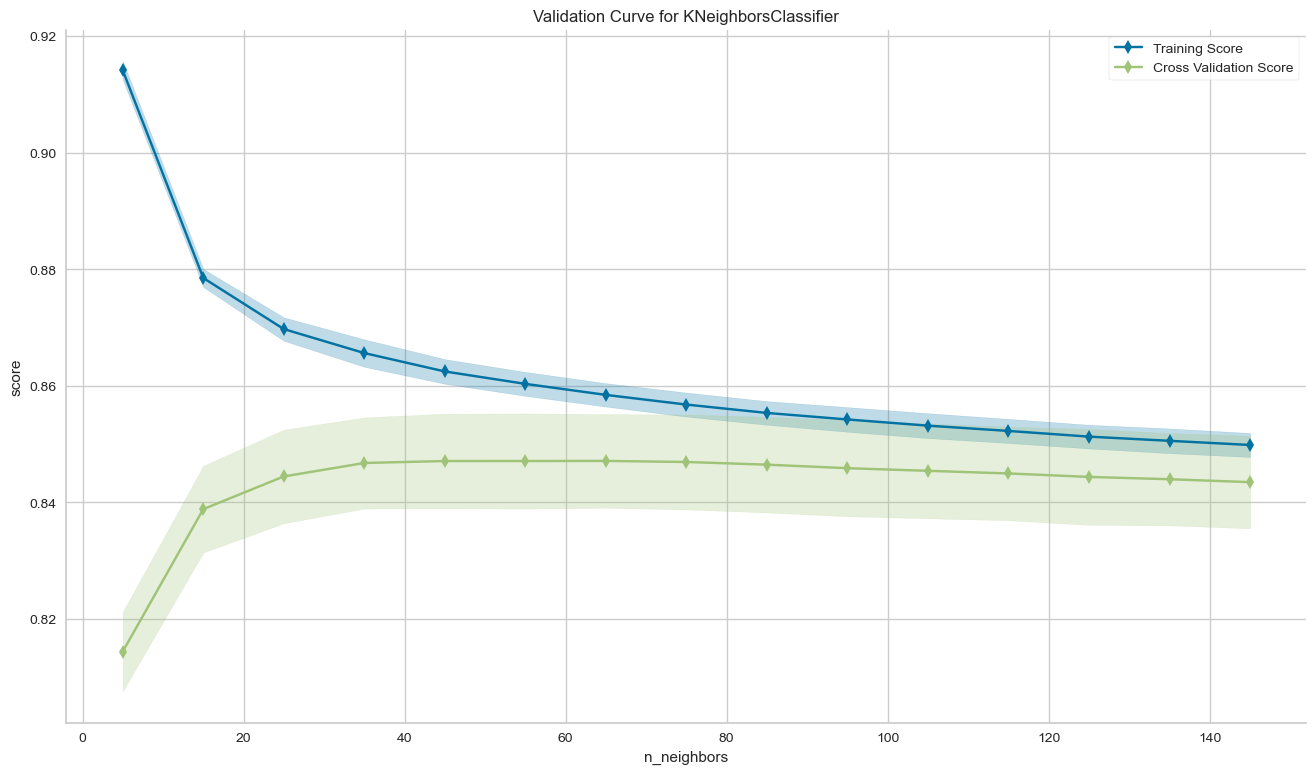

<Axes: title={'center': 'Validation Curve for KNeighborsClassifier'}, xlabel='n_neighbors', ylabel='score'>

In [48]:
fig, ax = plt.subplots(figsize=(16, 9))
valCurve = ValidationCurve(KNeighborsClassifier(),
                           param_name='n_neighbors',
                           param_range=nNeighbors,
                           cv = n_folds,
                           scoring=scoring,
                           ax=ax)
valCurve.fit(X, yBinary)
sns.despine()
valCurve.poof()

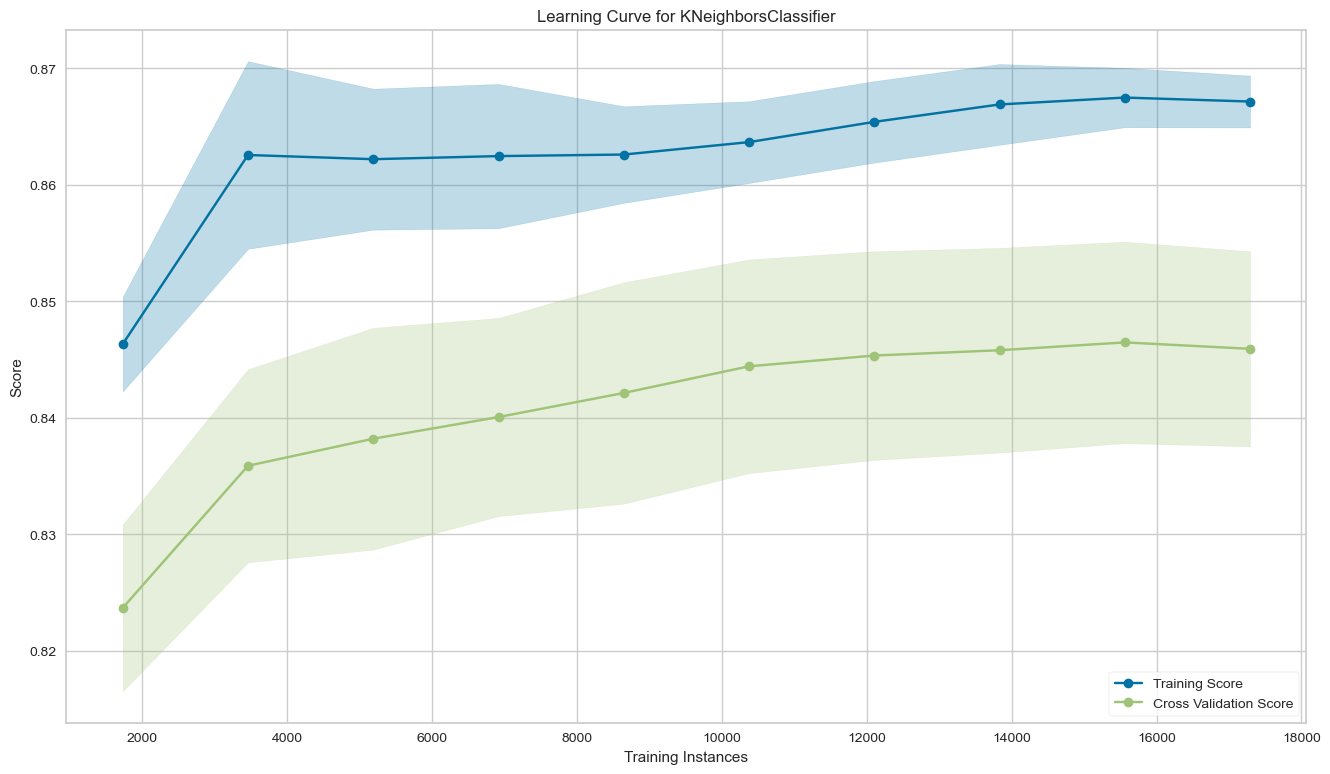

In [49]:
fig, ax = plt.subplots(figsize=(16, 9))
learningCurve = LearningCurve(KNeighborsClassifier(n_neighbors=best_k),
                              train_sizes=np.arange(.1,1.01, .1),
                              scoring=scoring,
                              cv=5,
                              ax=ax)
learningCurve.fit(X, yBinary)
learningCurve.poof()
sns.despine()             

In [50]:
#A few classification metrics

In [51]:
from sklearn.metrics import (classification_report, accuracy_score, zero_one_loss, roc_auc_score, brier_score_loss, jaccard_score, hinge_loss, f1_score, precision_recall_curve)

In [52]:
yScore = cross_val_predict(KNeighborsClassifier(best_k), 
                           X=X, 
                           y=yBinary, 
                           cv=5, 
                           n_jobs=-1, 
                           method='predict_proba')[:, 1]

In [53]:
pred_scores = dict(y_true=yBinary,y_score=yScore)

In [54]:
#ROC AUC

In [55]:
roc_auc_score(**pred_scores)

np.float64(0.8450174398865203)

In [56]:
#Precision-Recall
precision, recall, ts = precision_recall_curve(y_true=yBinary, y_score=yScore)
pr_curve = pd.DataFrame({'Precision': precision, 'Recall': recall})

In [57]:
f1 = pd.Series({t: f1_score(y_true=yBinary, y_pred=yScore>t) for t in ts})
best_threshold = f1.idxmax()

In [58]:
#Brier Score

In [59]:
brier_score_loss(y_true=yBinary, y_proba=yScore)

np.float64(0.16039168813008634)

In [60]:
y_pred = yScore > best_threshold
scores = dict(y_true = yBinary, y_pred = y_pred)

In [61]:
#Accuracy
accuracy_score(**scores)

0.7433489103780132

In [62]:
#Hinge Loss
hinge_loss(y_true = yBinary, pred_decision = y_pred)

np.float64(0.7593115254707815)

In [63]:
#Jaccard Similarity
jaccard_score(**scores)

np.float64(0.6191032067568496)